In [6]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [7]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

=== STARTING BB84 WITH ATTACKER (EVE) ===
Alice's bits:  00111101
Alice's bases: 10111001
Eve's bases:   01101101
Bob's bases:   10000011

Drawing the Quantum Circuit (Alice -> Eve -> Bob)...


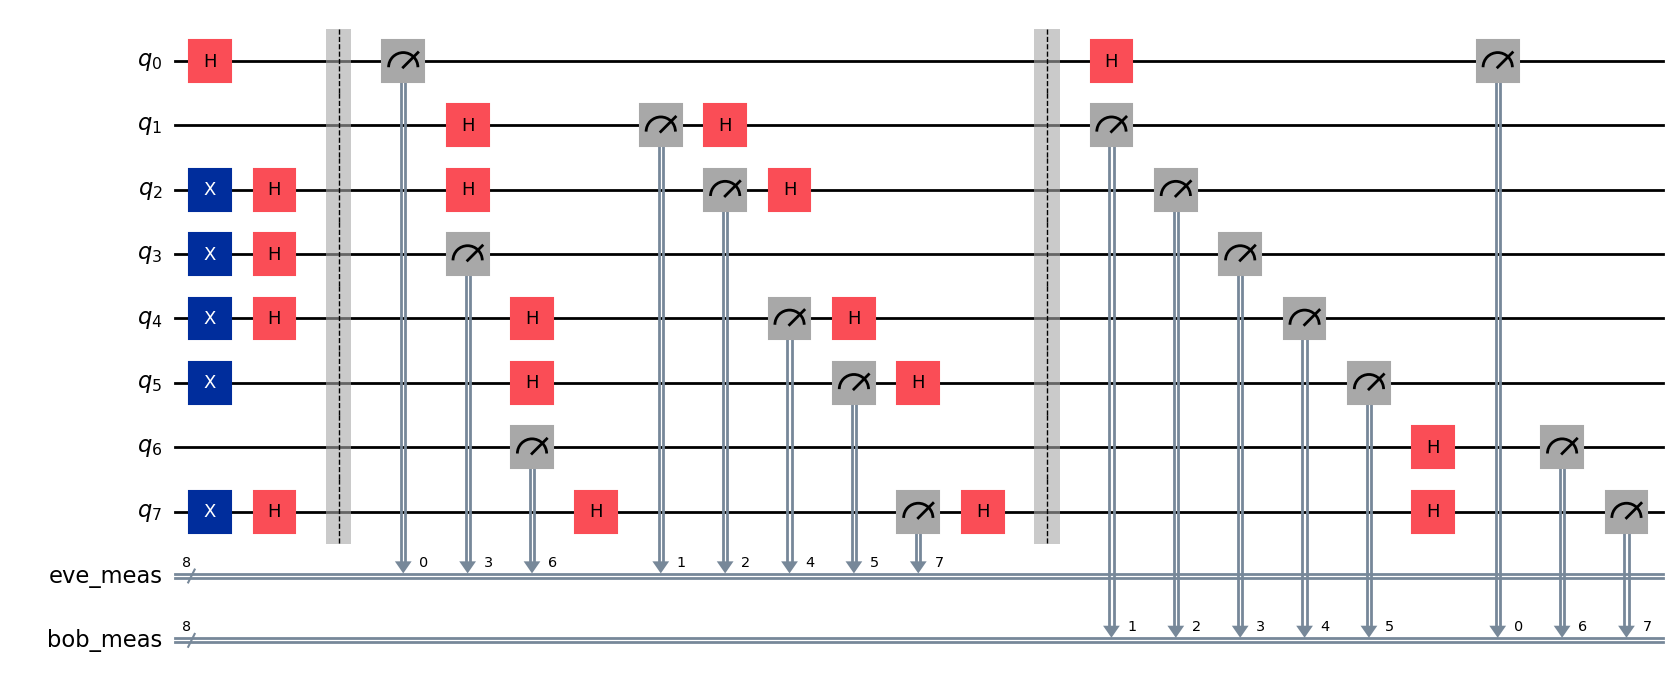


Plotting the Measurement Results (Format: Bob_bits Eve_bits)...


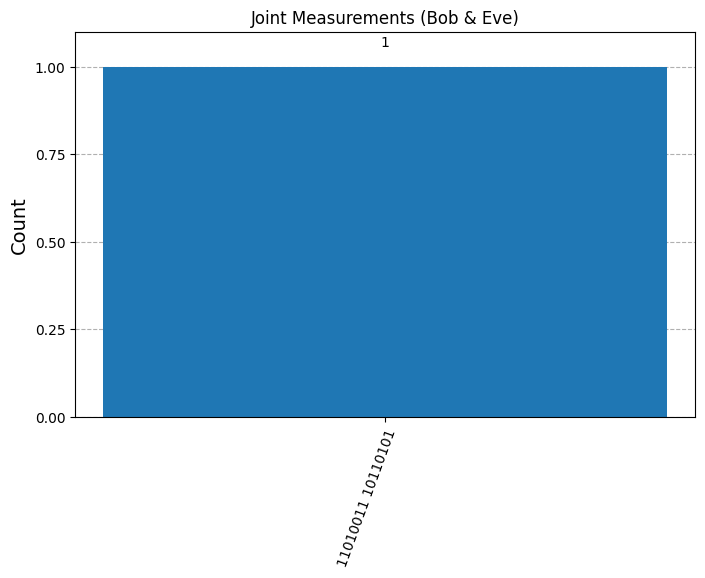


Sifted Key Length: 4 bits
Error Rate: 75.00%
-> ALERT: Attack detected! High error rate. Protocol aborted.


In [8]:
# --- CELL 3: BB84 WITH EVE (INTERCEPT-RESEND ATTACK) ---

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

def run_attacker_bb84_with_plots(num_qubits=8): # Reduced to 8 for visualization
    print("=== STARTING BB84 WITH ATTACKER (EVE) ===")

    # 1. ALICE PREPARES
    alice_bits = get_quantum_random_bits(num_qubits)
    alice_bases = get_quantum_random_bits(num_qubits)

    print(f"Alice's bits:  {alice_bits}")
    print(f"Alice's bases: {alice_bases}")

    qr = QuantumRegister(num_qubits, 'q')
    cr_eve = ClassicalRegister(num_qubits, 'eve_meas')
    cr_bob = ClassicalRegister(num_qubits, 'bob_meas')
    qc = QuantumCircuit(qr, cr_eve, cr_bob)

    for i in range(num_qubits):
        if alice_bits[i] == '1':
            qc.x(i)
        if alice_bases[i] == '1':
            qc.h(i)

    qc.barrier() # Visual separator

    # 2. EVE INTERCEPTS
    eve_bases = get_quantum_random_bits(num_qubits)
    print(f"Eve's bases:   {eve_bases}")

    for i in range(num_qubits):
        if eve_bases[i] == '1':
            qc.h(i)
        qc.measure(i, cr_eve[i])

        # Eve resends
        if eve_bases[i] == '1':
            qc.h(i)

    qc.barrier() # Visual separator

    # 3. BOB MEASURES
    bob_bases = get_quantum_random_bits(num_qubits)
    print(f"Bob's bases:   {bob_bases}")

    for i in range(num_qubits):
        if bob_bases[i] == '1':
            qc.h(i)
        qc.measure(i, cr_bob[i])

    # --- PLOT 1: THE CIRCUIT ---
    print("\nDrawing the Quantum Circuit (Alice -> Eve -> Bob)...")
    display(qc.draw("mpl"))

    # Run Simulation
    simulator = BasicSimulator()
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1).result()

    # --- PLOT 2: THE HISTOGRAM ---
    print("\nPlotting the Measurement Results (Format: Bob_bits Eve_bits)...")
    display(plot_histogram(result.get_counts(), title="Joint Measurements (Bob & Eve)", figsize=(8, 5)))

    raw_counts = list(result.get_counts().keys())[0]
    bob_res_str, eve_res_str = raw_counts.split(' ')
    bob_bits = bob_res_str[::-1]

    # 4. RECONCILIATION & ERROR CHECKING
    alice_key = []
    bob_key = []

    for i in range(num_qubits):
        if alice_bases[i] == bob_bases[i]:
            alice_key.append(alice_bits[i])
            bob_key.append(bob_bits[i])

    print(f"\nSifted Key Length: {len(alice_key)} bits")

    errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
    error_rate = errors / len(alice_key) if len(alice_key) > 0 else 0

    print(f"Error Rate: {error_rate * 100:.2f}%")

    if error_rate > 0.10:
        print("-> ALERT: Attack detected! High error rate. Protocol aborted.")
    else:
        print("-> SUCCESS: No attack detected.")

# Run the simulation
run_attacker_bb84_with_plots(8)